# **PREPROCESSING**    

# **Preprocessing Data NO₂ di Kwanyar, Bangkalan**

Notebook ini berisi tahapan preprocessing data hasil crawling konsentrasi gas NO₂ di wilayah Kwanyar, Bangkalan, Jawa Timur, sebelum dilakukan pemodelan menggunakan KNN Regression.

Dataset yang digunakan berasal dari hasil pengambilan data satelit melalui openEO API dan telah disimpan dalam format .csv dengan kolom:


*   tanggal
*   NO2


Tahap preprocessing ini dilakukan agar data siap digunakan pada KNN Regression. Langkah-langkahnya meliputi:


1.   Import library dan load data
2.   Konversi tanggal dan sorting
3.   Handling missing values (interpolasi)
4.   Pembuatan supervised data dengan lag features



# **Import Library Dan Load Datset**

In [1]:
# --- 1. Import Library ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load Dataset ---

df = pd.read_csv("data/NO2_Kwanyar.csv")

# --- 3. Tampilkan 5 data pertama ---
print("=== 5 Data Pertama ===")
display(df.head())

# --- 4. Info tambahan dataset ---
print("\n=== Info Dataset ===")
print(df.info())

=== 5 Data Pertama ===


,Tanggal,NO2
0,2023-01-01,NaN
1,2023-01-02,NaN
2,2023-01-03,NaN
3,2023-01-04,0.000034
4,2023-01-05,0.000031



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  1016 non-null   object 
 1   NO2      516 non-null    float64
dtypes: float64(1), object(1)
memory usage: 16.0+ KB
None


# **Handling Missing Values**

Jika terdapat nilai NO₂ yang kosong, maka akan diisi menggunakan interpolasi linear, karena data bersifat deret waktu (time series).

In [2]:
# Cek jumlah missing value sebelum interpolasi
print("Sebelum interpolasi:")
print(df.isnull().sum())

# Interpolasi nilai yang hilang
df['NO2'] = df['NO2'].interpolate(method='linear')

# Cek ulang setelah interpolasi
print("\nSetelah interpolasi:")
print(df.isnull().sum())


Sebelum interpolasi:
Tanggal      0
NO2        500
dtype: int64

Setelah interpolasi:
Tanggal    0
NO2        3
dtype: int64


Visualisasikan Hasil Interpolasi

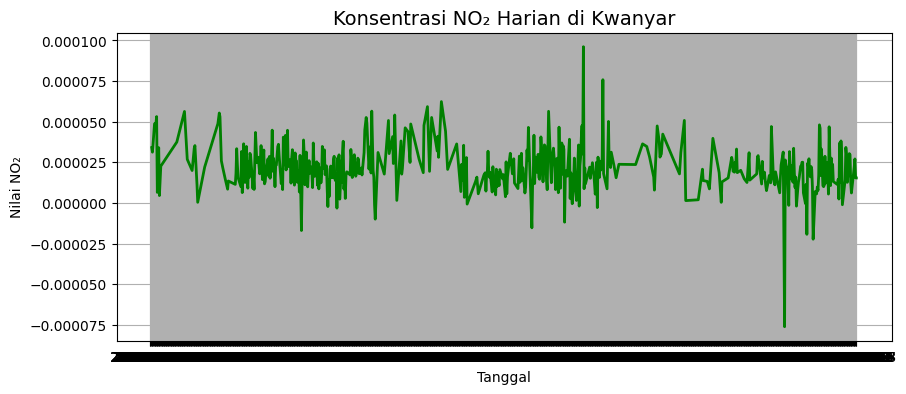

In [3]:
# --- 5. Visualisasi awal ---
plt.figure(figsize=(10, 4))
plt.plot(df['Tanggal'], df['NO2'], color='green', linewidth=2)
plt.title('Konsentrasi NO₂ Harian di Kwanyar', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Nilai NO₂')
plt.grid(True)
plt.show()

# **Pembuatan Supervised Data dengan Lag Features**

Agar data time series dapat digunakan untuk prediksi, kita perlu mengubahnya menjadi bentuk supervised learning, yaitu dengan menambahkan fitur lag (nilai NO₂ pada hari-hari sebelumnya).

3 lag features:

NO2_t-1 → NO₂ satu hari sebelumnya

NO2_t-2 → dua hari sebelumnya

NO2_t-3 → tiga hari sebelumnya

In [4]:
# Membuat fitur lag (1, 2, 3 hari sebelumnya)
for lag in range(1, 4):
    df[f'NO2_t-{lag}'] = df['NO2'].shift(lag)

# Hapus baris yang memiliki NaN akibat pergeseran
df_supervised = df.dropna().reset_index(drop=True)

print("Jumlah data setelah pembentukan lag features:", len(df_supervised))
df_supervised.head()

Jumlah data setelah pembentukan lag features: 1010


,Tanggal,NO2,NO2_t-1,NO2_t-2,NO2_t-3
0,2023-01-07,0.000043,0.000037,0.000031,0.000034
1,2023-01-08,0.000049,0.000043,0.000037,0.000031
2,2023-01-09,0.000049,0.000049,0.000043,0.000037
3,2023-01-10,0.000049,0.000049,0.000049,0.000043
4,2023-01-11,0.000053,0.000049,0.000049,0.000049


# **Simpan Dataset Hasil Preprocessing**

Dataset hasil preprocessing (sudah bersih dan berbentuk supervised) disimpan untuk digunakan pada tahap pemodelan KNN Regression.

In [5]:
# Simpan hasil preprocessing ke file CSV
output_path = "data/NO2_Kwanyar_Preprocessed.csv"
df_supervised.to_csv(output_path, index=False)

print(f"✅ Data hasil preprocessing berhasil disimpan di: {output_path}")
print("Kamu bisa melihat atau mengunduh file tersebut langsung di panel Explorer (folder 'tugas/data').")


✅ Data hasil preprocessing berhasil disimpan di: data/NO2_Kwanyar_Preprocessed.csv
Kamu bisa melihat atau mengunduh file tersebut langsung di panel Explorer (folder 'tugas/data').


# **Visualisasi Pola NO₂ dan Lag-nya**

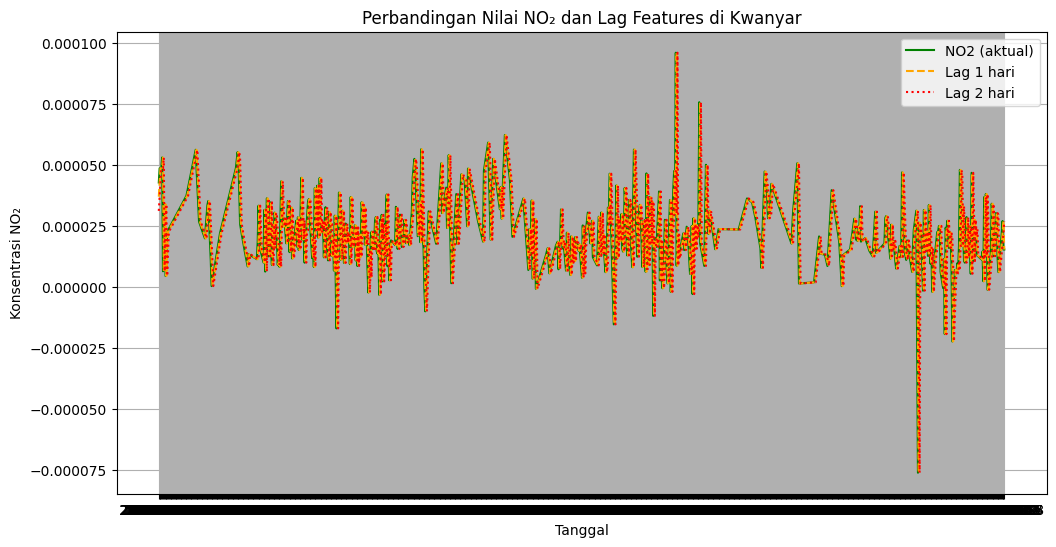

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df_supervised['Tanggal'], df_supervised['NO2'], label='NO2 (aktual)', color='green')
plt.plot(df_supervised['Tanggal'], df_supervised['NO2_t-1'], label='Lag 1 hari', linestyle='--', color='orange')
plt.plot(df_supervised['Tanggal'], df_supervised['NO2_t-2'], label='Lag 2 hari', linestyle=':', color='red')
plt.title("Perbandingan Nilai NO₂ dan Lag Features di Kwanyar")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.legend()
plt.grid(True)
plt.show()